# DIFUSCO — Architecture & Theory

**Sun & Yang, NeurIPS 2023** — *DIFUSCO: Graph-based Diffusion Solvers for Combinatorial Optimization*

This notebook builds up DIFUSCO completely from scratch.
No prior knowledge of diffusion models is assumed — only basic Python and a rough idea of what a neural network is.

---

**Contents**

1. The Problem Representation
2. The Big Idea — What is Diffusion?
3. The Noise Schedule
4. The Forward Process — Adding Noise
5. The Reverse Process — What the Model Learns
6. The Architecture
7. Training — The Denoising Game
8. Inference — Running the Reverse Chain
9. Summary and Comparison with the GNN


In [20]:
import sys, os
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from data  import (random_instance, nn_tour_labels, tour_length, greedy_decode,
                   generate_time_windows, generate_perturbations, build_tsptwd_features)
from model import DifuscoModel, MODEL_SIZES, SinusoidalTimeEmbedding
from train import NoiseSchedule, forward_diffuse

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'font.size': 9})
torch.manual_seed(0)
print('Setup complete.')


Setup complete.


---
## 1  The Problem Representation

Before we can train any model, we need to decide: **what is the output?**

### Option A — Output the tour as a sequence

Output a list of node indices: `[0, 3, 1, 4, 2]`.  
Simple, but awkward to train because the length changes with $n$.

### Option B — Output an edge probability matrix 

Output an $n \times n$ matrix where entry $(i, j)$ is:
> *"How confident am I that the optimal tour uses edge $i \to j$?"*

**DIFUSCO uses Option B.** The ideal, perfectly correct output is a **binary adjacency matrix** $y_0$:

$$y_0[i,j] = \begin{cases} 1 & \text{edge } (i \to j) \text{ is in the tour} \\ 0 & \text{otherwise} \end{cases}$$

For a valid tour on $n$ nodes:
- Every row sums to exactly **2** (one outgoing edge, one incoming edge)
- The matrix is **symmetric** — if the tour goes $i \to j$ it also goes $j \to i$


Tour: 0 → 2 → 4 → 1 → 3 → 0

Binary adjacency matrix y₀  (row i, col j = 1 means edge i→j in tour):
[[0 0 1 1 0]
 [0 0 0 1 1]
 [1 0 0 0 1]
 [1 1 0 0 0]
 [0 1 1 0 0]]

Row sums (each should be 2): [2, 2, 2, 2, 2]


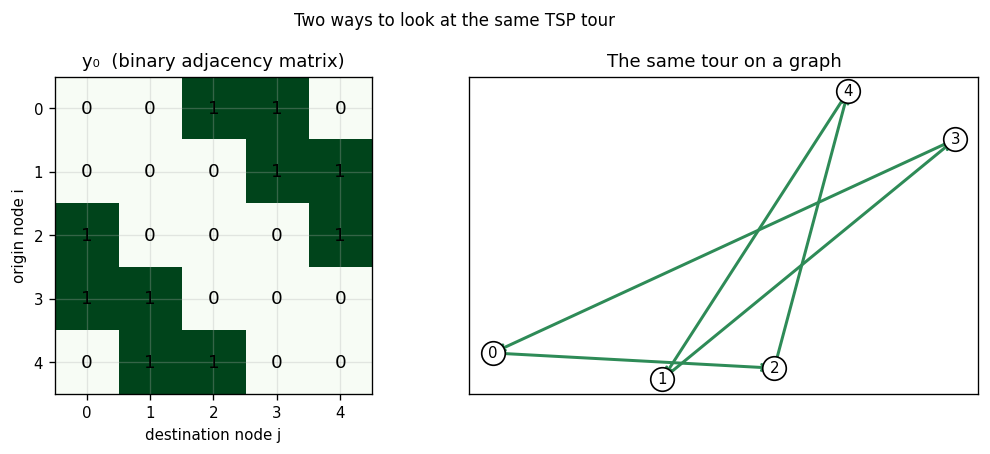

In [21]:
# ── Concrete example: tour 0→2→4→1→3→0 on 5 nodes ──────────────────────────
tour = [0, 2, 4, 1, 3]
n    = 5

y0 = torch.zeros(n, n)
for k in range(n):
    i, j = tour[k], tour[(k + 1) % n]
    y0[i, j] = 1.0
    y0[j, i] = 1.0   # symmetric: both directions

print('Tour:', ' → '.join(map(str, tour + [tour[0]])))
print()
print('Binary adjacency matrix y₀  (row i, col j = 1 means edge i→j in tour):')
print(y0.int().numpy())
print()
print('Row sums (each should be 2):', y0.sum(dim=1).int().tolist())

# ── Visualise side by side ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))

# Matrix heatmap
axes[0].imshow(y0.numpy(), cmap='Greens', vmin=0, vmax=1)
for i in range(n):
    for j in range(n):
        axes[0].text(j, i, int(y0[i,j].item()), ha='center', va='center', fontsize=11)
axes[0].set(title='y₀  (binary adjacency matrix)',
            xlabel='destination node j', ylabel='origin node i')
axes[0].set_xticks(range(n)); axes[0].set_yticks(range(n))

# Tour on graph
coords = random_instance(n, seed=3)
for k in range(n):
    i, j = tour[k], tour[(k+1)%n]
    axes[1].annotate('', xy=coords[j], xytext=coords[i],
                     arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.8))
axes[1].scatter(coords[:,0], coords[:,1], c='white', edgecolors='black', s=200, zorder=5)
for i,(x,y) in enumerate(coords):
    axes[1].text(x, y, str(i), ha='center', va='center', fontsize=9, zorder=6)
axes[1].set(title='The same tour on a graph', xticks=[], yticks=[])

plt.suptitle('Two ways to look at the same TSP tour', fontsize=10)
plt.tight_layout()
plt.savefig('figures/theory_representation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 2  The Big Idea — What is Diffusion?

### The photograph analogy

Imagine a sharp photograph of a cat.
You apply a tiny amount of random static to it. Then more. Then more.  
After **1000 steps** you have pure static — the cat has completely disappeared.

```
[sharp cat]  →  [slight blur]  →  [noisy]  →  [heavy static]  →  [pure noise]
    t=0             t=200           t=500          t=800            t=1000
```

Now — if you train a neural network to **reverse each individual small step**  
("given this image at noise level $t$, what did it look like at level $t-1$?")  
then at test time you can do something remarkable:

1. **Start from pure static** — sample random noise from $\mathcal{N}(0, I)$
2. **Run the network 1000 times**, each time removing a little noise
3. **Converge to a sharp photo of a cat** — one you've never seen before

This is a **Denoising Diffusion Probabilistic Model (DDPM)**.  
It is the engine behind Stable Diffusion, DALL·E 2, and Midjourney.

---

### Applied to TSP — replacing pixels with edges

DIFUSCO replaces the photograph with a **binary tour adjacency matrix** $y_0$.  
Everything else is identical:

| Image diffusion | TSP diffusion (DIFUSCO) |
|---|---|
| Pixel values in $[0, 255]$ | Edge values $\in \{0, 1\}$ |
| Add Gaussian noise to pixels | Add Gaussian noise to edge entries |
| Model predicts the clean image | Model predicts the clean tour matrix |
| Start from $\mathcal{N}(0,I)$ image | Start from $\mathcal{N}(0,I)$ edge matrix |

The critical extra ingredient: at **every denoising step** the model also sees the  
**graph structure** — coordinates, distances, time windows.  
This guides the denoising toward valid, short tours rather than random noise patterns.

---

### Why is this better than the GNN's single forward pass?

The GNN answers *"what tour do you think this is?"* in **one shot** — no second chances.

DIFUSCO iteratively asks *"given this noisy guess, can you make it slightly better?"* — **50 to 1000 times**.  
Each step can fix mistakes from the previous step.  
The model effectively does a gradient descent **in solution space** at test time.


---
## 3  The Noise Schedule

We need a precise recipe for how much noise to add at each step.  
This is the **noise schedule**, defined by three sequences for $t = 1, 2, \ldots, T$ (typically $T = 1000$).

---

### $\beta_t$ — noise variance added at step $t$

$$\beta_t = \underbrace{\beta_{\min}}_{\substack{\text{starting value}\\\approx 0}} + \underbrace{(t-1) \cdot \frac{\beta_{\max} - \beta_{\min}}{T - 1}}_{\text{linear ramp from 0 to } \beta_{\max} - \beta_{\min}}$$

**where:**

| Symbol | Value | Meaning |
|--------|-------|---------|
| $\beta_{\min}$ | $0.0001$ | Noise added at the very first step — tiny, almost nothing |
| $\beta_{\max}$ | $0.02$ | Noise added at the very last step — still small in absolute terms |
| $T$ | $1000$ | Total number of diffusion steps |
| $\frac{t-1}{T-1}$ | $\in [0, 1]$ | Fractional position of step $t$ — 0 at the start, 1 at the end |

At early steps the signal is barely disturbed; at later steps it degrades quickly.

---

### $\alpha_t$ — fraction of signal **kept** at step $t$

$$\alpha_t = \underbrace{1}_{\text{full signal}} - \underbrace{\beta_t}_{\text{noise variance}} = \underbrace{1 - \beta_t}_{\text{survival fraction}}$$

**where:** $\alpha_t \in (0, 1)$ is close to 1 (nearly all signal kept) when $\beta_t$ is small.  
Example: if $\beta_t = 0.01$, then $\alpha_t = 0.99$ — 99% of the signal survives this one step.

---

### $\bar{\alpha}_t$ — **cumulative** signal survival from step 1 to $t$

$$\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s = \underbrace{\alpha_1 \cdot \alpha_2 \cdots \alpha_t}_{\text{running product of all survival fractions}}$$

**where:** $\bar{\alpha}_t$ is the most important quantity.  
It measures **how much of the original $y_0$ survives** after $t$ rounds of noise addition.

> **Intuition:** each $\alpha_s \approx 0.99$, so after $t$ multiplications the product decays exponentially.
> Think of it as compound interest in reverse — each step shaves off a tiny fraction of the signal.

| $t$ | $\bar{\alpha}_t$ | What $y_t$ looks like |
|-----|------------------|----------------------|
| 1 | ≈ 0.9999 | Almost identical to $y_0$ |
| 100 | ≈ 0.95 | Slightly smeared |
| 500 | ≈ 0.07 | Mostly noise |
| 1000 | ≈ 0.00003 | Pure static |


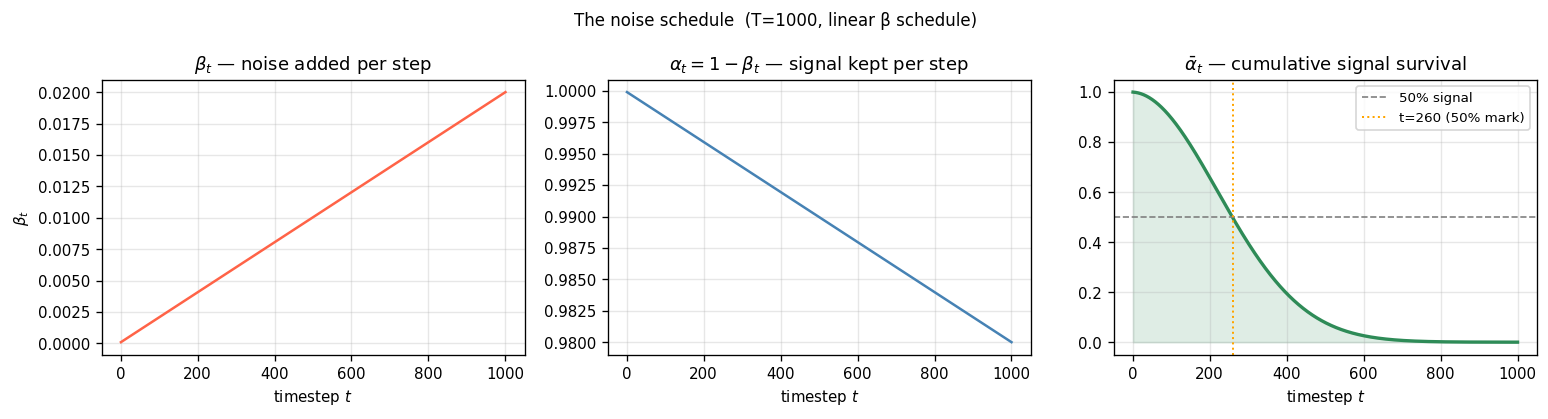

Signal drops below 50% at t ≈ 260
  ᾱ_1     = 0.999900
  ᾱ_100   = 0.897018
  ᾱ_500   = 0.078587
  ᾱ_1000  = 0.000040


In [22]:
schedule = NoiseSchedule(T=1000)
t_vals = torch.arange(1, 1001).float()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(t_vals, schedule.betas, color='tomato', lw=1.5)
axes[0].set(title=r'$\beta_t$ — noise added per step',
            xlabel='timestep $t$', ylabel=r'$\beta_t$')

axes[1].plot(t_vals, schedule.alphas, color='steelblue', lw=1.5)
axes[1].set(title=r'$\alpha_t = 1 - \beta_t$ — signal kept per step',
            xlabel='timestep $t$')

ab = schedule.alpha_bars
axes[2].plot(t_vals, ab, color='seagreen', lw=2)
axes[2].fill_between(t_vals, 0, ab.numpy(), alpha=0.15, color='seagreen')
axes[2].axhline(0.5, ls='--', color='grey', lw=1, label='50% signal')
half_t = (ab < 0.5).nonzero()[0].item() + 1
axes[2].axvline(half_t, ls=':', color='orange', lw=1.2, label=f't={half_t} (50% mark)')
axes[2].set(title=r'$\bar{{\alpha}}_t$ — cumulative signal survival', xlabel='timestep $t$')
axes[2].legend(fontsize=8)

plt.suptitle('The noise schedule  (T=1000, linear β schedule)', fontsize=10)
plt.tight_layout()
plt.savefig('figures/theory_noise_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Signal drops below 50% at t ≈ {half_t}')
for t_ex in [1, 100, 500, 1000]:
    print(f'  ᾱ_{t_ex:<5} = {schedule.alpha_bar(t_ex).item():.6f}')


---
## 4  The Forward Process — Adding Noise

The beauty of diffusion is that you can **jump to any noise level $t$ directly**,  
without simulating all the intermediate steps.  
This is the **reparameterisation trick** — the most important formula in DIFUSCO:

$$\boxed{
  \underbrace{y_t}_{\substack{\text{noisy matrix}\\\text{at step }t}}
  = \underbrace{\sqrt{\bar{\alpha}_t}}_{\text{signal weight}} \;
    \underbrace{y_0}_{\text{clean tour}}
  + \underbrace{\sqrt{1 - \bar{\alpha}_t}}_{\text{noise weight}} \;
    \underbrace{\varepsilon}_{\text{pure noise}}, \qquad
    \varepsilon \sim \mathcal{N}(0, I)
}$$

**where:**

| Symbol | Shape | Meaning |
|--------|-------|---------|
| $y_0$ | $(n,n)$ | The **clean tour matrix** — our training label; entries are 0 or 1 |
| $\varepsilon$ | $(n,n)$ | **Pure Gaussian noise** — `torch.randn_like(y0)`; each entry is $\sim\mathcal{N}(0,1)$ |
| $\bar{\alpha}_t$ | scalar | **Cumulative signal survival** — computed from the noise schedule (Section 3) |
| $\sqrt{\bar{\alpha}_t}$ | scalar | **Signal weight** — how much of the original tour survives; near 1 for small $t$, near 0 for large $t$ |
| $\sqrt{1-\bar{\alpha}_t}$ | scalar | **Noise weight** — how loud the noise is; near 0 for small $t$, near 1 for large $t$ |
| $y_t$ | $(n,n)$ | The **corrupted tour** at timestep $t$ — what the model receives as input |

> **Balance property:** $\bigl(\sqrt{\bar{\alpha}_t}\bigr)^2 + \bigl(\sqrt{1-\bar{\alpha}_t}\bigr)^2 = \bar{\alpha}_t + (1-\bar{\alpha}_t) = 1$.  
> The signal and noise contributions are normalised — total variance is preserved at every $t$.

**At $t = 1$:** $\sqrt{\bar{\alpha}_1} \approx 1$ → $y_1 \approx y_0$ (barely touched)  
**At $t = 1000$:** $\sqrt{\bar{\alpha}_{1000}} \approx 0$ → $y_{1000} \approx \varepsilon$ (pure noise)

> **Why is this useful for training?**  
> We never have to simulate 1000 noise steps one by one.  
> To get a training example at noise level $t$, we just pick $t$ randomly, sample one $\varepsilon$,  
> and compute $y_t$ in a **single line**. This makes training extremely fast.


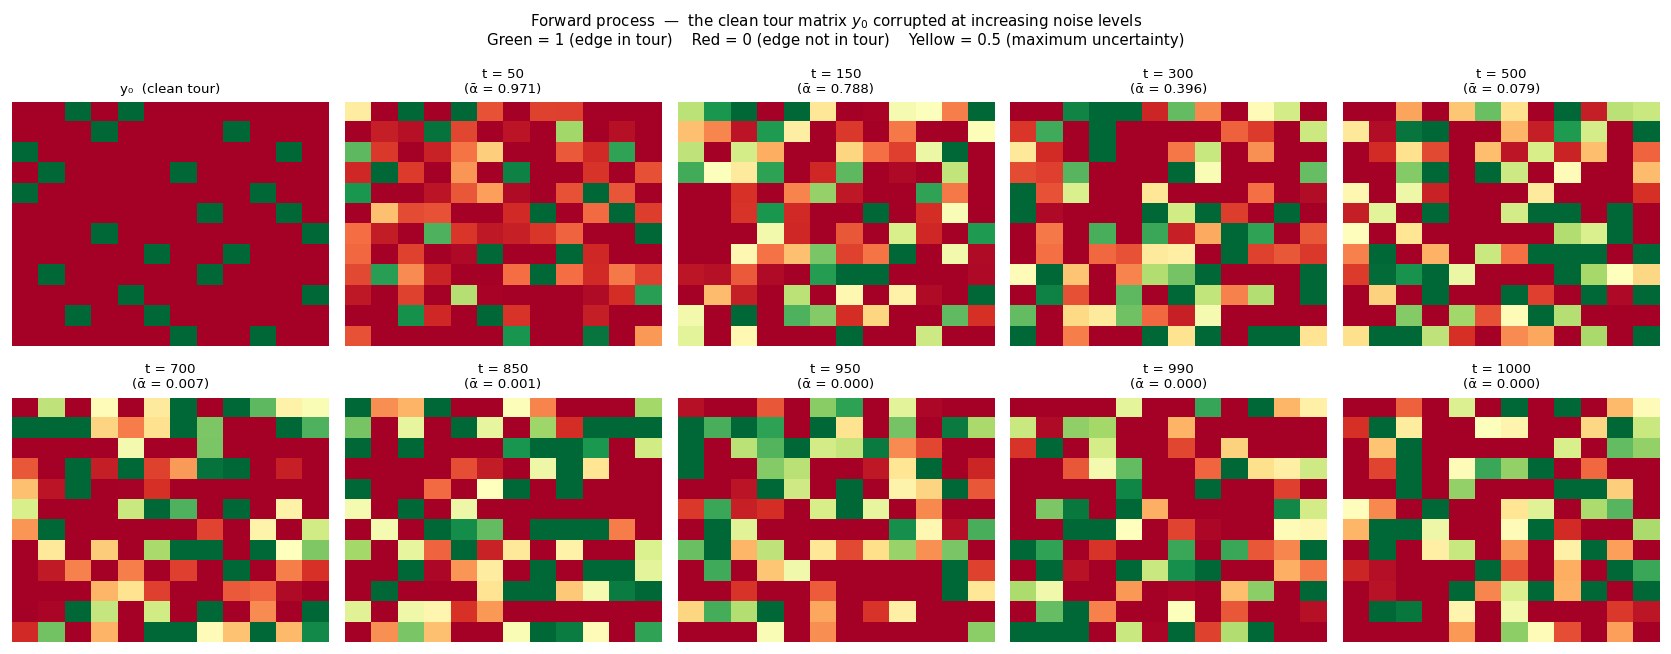

In [23]:
# ── Show how a real tour matrix degrades at different noise levels ──────────
coords_ex = random_instance(12, seed=5)
y0_ex     = nn_tour_labels(coords_ex)   # (12,12) binary tour matrix

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
t_show = [0, 50, 150, 300, 500, 700, 850, 950, 990, 1000]

for ax, t in zip(axes.flat, t_show):
    if t == 0:
        mat   = y0_ex
        title = 'y₀  (clean tour)'
    else:
        mat, _ = forward_diffuse(y0_ex, t=t, schedule=schedule)
        ab_val = schedule.alpha_bar(t).item()
        title  = f't = {t}\n(ᾱ = {ab_val:.3f})'

    ax.imshow(mat.numpy(), cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.suptitle(
    'Forward process  —  the clean tour matrix $y_0$ corrupted at increasing noise levels\n'
    'Green = 1 (edge in tour)    Red = 0 (edge not in tour)    Yellow = 0.5 (maximum uncertainty)',
    fontsize=9)
plt.tight_layout()
plt.savefig('figures/theory_forward_process.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 5  The Reverse Process — What the Model Learns

### What the model predicts

Given the noisy matrix $y_t$, the graph $x$, and the timestep $t$, the model predicts the clean $y_0$:

$$\hat{y}_0 = f_\theta\!\bigl(\underbrace{y_t}_{\substack{\text{noisy tour}\\\text{matrix}}},\;\underbrace{x}_{\substack{\text{graph features}\\\text{(coords, TW, ...})}},\;\underbrace{t}_{\substack{\text{current noise}\\\text{level}}}\bigr)$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $\hat{y}_0 \in (0,1)^{n\times n}$ | Model's predicted probability for each edge to be in the clean tour |
| $f_\theta$ | The GNN (DifuscoModel) with learnable parameters $\theta$ |
| $y_t$ | The noisy tour matrix at step $t$ — computed by the forward process |
| $x$ | Graph-level features: node coordinates, time windows, edge distances, perturbations |
| $t$ | The timestep — tells the model how much noise is present so it calibrates its confidence |

---

### DDPM — the stochastic reverse step

To go from $y_t$ to $y_{t-1}$, use the **posterior formula** (derived from Bayes' rule on Gaussians):

$$y_{t-1} = \underbrace{\frac{\sqrt{\bar{\alpha}_{t-1}}\,\beta_t}{1 - \bar{\alpha}_t}}_{c_1\;:\;\text{weight on }\hat{y}_0} \hat{y}_0 \;+\; \underbrace{\frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t}}_{c_2\;:\;\text{weight on }y_t} y_t \;+\; \underbrace{\sqrt{\frac{(1-\bar{\alpha}_{t-1})\,\beta_t}{1-\bar{\alpha}_t}}}_{\sigma_t\;:\;\text{posterior std dev}} \varepsilon$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $c_1$ | Weight on the **predicted clean tour** $\hat{y}_0$ — grows as $t$ decreases (we trust the prediction more near the end) |
| $c_2$ | Weight on the **current noisy state** $y_t$ — dominates when $t$ is large (prediction is unreliable early on) |
| $\sigma_t$ | Standard deviation of the posterior — quantifies remaining uncertainty; approaches 0 as $t \to 1$ |
| $\varepsilon \sim \mathcal{N}(0,I)$ | Freshly sampled noise — added intentionally to maintain diversity across runs |
| $\bar{\alpha}_{t-1}$ | Cumulative signal survival up to step $t-1$ (one step earlier in the reverse chain) |
| $\beta_t, \alpha_t$ | Per-step noise variance and signal retention (from the noise schedule) |

This is a **weighted blend** of the model's prediction and the current noisy state.  
At small $t$ (near the end), $c_1 \gg c_2$ — we trust $\hat{y}_0$.  
At large $t$ (near the start), $c_2 \gg c_1$ — we stay close to $y_t$ since $\hat{y}_0$ is unreliable.

---

### DDIM — deterministic fast sampling

The noise term $\sigma_t \varepsilon$ can be **removed entirely** (DDIM, Song et al. 2021).

**Step 1 — estimate the noise direction:**

$$\underbrace{\delta}_{\text{noise direction}} = \frac{\overbrace{y_t}^{\text{current noisy state}} - \overbrace{\sqrt{\bar{\alpha}_t}\,\hat{y}_0}^{\text{predicted signal component}}}{\underbrace{\sqrt{1 - \bar{\alpha}_t}}_{\text{normalise to unit scale}}}$$

> $\delta$ is the residual between $y_t$ and the predicted signal — it estimates "what direction is the noise in?".
> Dividing by $\sqrt{1-\bar{\alpha}_t}$ makes it a **unit-variance** direction vector.

**Step 2 — update to the previous noise level:**

$$\underbrace{y_{t_\text{prev}}}_{\text{less noisy state}} = \underbrace{\sqrt{\bar{\alpha}_{t_\text{prev}}}}_{\text{signal weight at }t_\text{prev}}\,\hat{y}_0 \;+\; \underbrace{\sqrt{1 - \bar{\alpha}_{t_\text{prev}}}}_{\text{noise weight at }t_\text{prev}}\;\delta$$

> This re-uses the same noise direction $\delta$ but **rescales it** for the new noise level $\bar{\alpha}_{t_\text{prev}}$.  
> No fresh $\varepsilon$ is sampled — the update is fully deterministic.

**Key advantage:** because it's deterministic, we can **skip timesteps**.  
Jump from $t = 1000$ directly to $t = 980$, then to $t = 960$, ...  
Only **50 steps** instead of 1000, with almost identical quality.  
This is `sample(..., ddim=True, n_steps=50)` in our code.


---
## 6  The Architecture

The model $f_\theta$ takes $(y_t, x, t)$ and outputs $\hat{y}_0$.  
It has three components:

```
Input
  x  = node features   (n, node_dim)     ← coordinates, TW, perturbation features
  y_t = noisy edges    (n, n)             ← the key DIFUSCO-specific input
  t  = timestep        scalar

────────────────────────────────────────────────────────────────
  SinusoidalTimeEmbedding(t)  →  t_emb  (d,)
  Linear(node_feats)          →  h      (n, d)      node embeddings
  Linear([dist | α | y_t])    →  e      (n, n, d)   edge embeddings

  for layer in L × DifuscoGNNLayer:
      h, e = layer(h, e, t_emb)   ← timestep injected every layer

  MLP(e) → sigmoid  →  ŷ₀  (n, n)  ∈ (0, 1)
────────────────────────────────────────────────────────────────
```

### 6.1  Sinusoidal Timestep Embedding

The model sees the same architecture at $t = 1$ (almost clean) and $t = 999$ (pure noise).  
Without knowing $t$, it cannot tell these apart.  
We encode $t$ as a $d$-dimensional vector using **sinusoidal frequencies**:

$$\text{emb}(t)_{2k}   = \sin\!\left(\frac{t}{10000^{2k/d}}\right), \qquad
  \text{emb}(t)_{2k+1} = \cos\!\left(\frac{t}{10000^{2k/d}}\right)$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $t$ | The current timestep $\in \{1, \ldots, T\}$ — the quantity being encoded |
| $k$ | Frequency index, $k = 0, 1, \ldots, d/2 - 1$ — each dimension uses a different frequency |
| $d$ | Embedding dimension (e.g. 64 for the small preset) |
| $10000^{2k/d}$ | The period of oscillation for dimension $k$ — grows exponentially with $k$ |
| $\sin/\cos$ | Alternating functions ensure every $t$ produces a unique vector |

Low-$k$ dimensions oscillate **slowly** (distinguish large-scale time differences).  
High-$k$ dimensions oscillate **quickly** (distinguish fine-grained differences).  
Together they give the model a unique **fingerprint** for every timestep.

Then a small MLP (`Linear → SiLU → Linear`) lifts the vector to hidden dimension $d$.

### 6.2  GNN Layers (conditioned on $t$)

Identical to the GNN (Joshi et al., 2019) with one key change: the timestep embedding  
is injected into edge features at every layer.

**Edge update:**

$$e_{ij}^{(\ell)} = \underbrace{\text{ReLU}}_{\text{activation}}\!\Bigl(\underbrace{\text{LN}}_{\substack{\text{Layer}\\\text{Norm}}}\bigl(\underbrace{W_1 h_i^{(\ell-1)}}_{\text{source node}} + \underbrace{W_2 h_j^{(\ell-1)}}_{\text{target node}} + \underbrace{W_3 e_{ij}^{(\ell-1)}}_{\text{previous edge}} + \underbrace{W_t\, t_{\text{emb}}}_{\substack{\text{timestep}\\\text{conditioning}}}\bigr)\Bigr)$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $h_i^{(\ell-1)}, h_j^{(\ell-1)}$ | Node embeddings of the source and target nodes from the previous layer |
| $e_{ij}^{(\ell-1)}$ | Edge embedding from the previous layer — carries information about edge $(i \to j)$ |
| $W_1, W_2, W_3 \in \mathbb{R}^{d \times d}$ | Learnable weight matrices projecting each input into the same space |
| $W_t \in \mathbb{R}^{d \times d}$ | Learnable projection for the timestep — teaches the model to modulate by noise level |
| $t_{\text{emb}}$ | Sinusoidal embedding of the current timestep $t$ (computed once, shared across all layers) |
| LN | Layer Normalisation — stabilises training by normalising activations |
| ReLU | Rectified Linear Unit: $\max(0, x)$ — introduces non-linearity |

**Node update (residual):**

$$h_i^{(\ell)} = h_i^{(\ell-1)} + \underbrace{\text{ReLU}\Bigl(\text{LN}\bigl(W_4 h_i^{(\ell-1)} + \textstyle\sum_j \underbrace{\eta_{ij}}_{\text{attention gate}} \cdot \underbrace{W_5 e_{ij}^{(\ell)}}_{\text{projected edge}}\bigr)\Bigr)}_{\text{aggregated neighbourhood message}}$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $h_i^{(\ell-1)}$ | Previous node embedding — added back via the **residual connection** (like ResNet) to preserve gradient flow |
| $\eta_{ij} = \text{softmax}_j(\text{gate}(e_{ij}^{(\ell)}))$ | **Attention weight** — soft selection over outgoing edges; sums to 1 over all $j$ |
| $W_4 \in \mathbb{R}^{d \times d}$ | Projects the node's own previous embedding |
| $W_5 \in \mathbb{R}^{d \times d}$ | Projects incoming edge messages before aggregation |
| $\sum_j \eta_{ij} \cdot W_5 e_{ij}^{(\ell)}$ | **Weighted sum** of neighbour messages — each edge contributes proportionally to its attention score |

### 6.3  Output head

A small MLP maps each final edge embedding to a scalar, then a sigmoid converts it to a probability:

$$\hat{y}_0[i,j] = \underbrace{\sigma}_{\substack{\text{sigmoid:}\\\sigma(z)=1/(1+e^{-z})}}\!\Bigl(\underbrace{\text{MLP}}_{\substack{\text{two linear layers}\\\text{+ ReLU}}}\bigl(\underbrace{e_{ij}^{(L)}}_{\substack{\text{final edge embedding}\\\text{after }L\text{ GNN layers}}}\bigr)\Bigr) \in (0, 1)$$

**where:** $\sigma$ squashes any real value to $(0, 1)$, making $\hat{y}_0[i,j]$ directly interpretable  
as the probability that edge $(i \to j)$ belongs to the optimal tour.


In [24]:
d, L, T_s = MODEL_SIZES['small']   # (64, 4, 500)
model = DifuscoModel(d=d, L=L, node_dim=5, edge_dim=2)

print(f'Model preset: small   d={d}  L={L}  T={T_s}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}\n')

components = [
    ('SinusoidalTimeEmbedding', model.time_emb),
    ('node_in  (Linear node_dim→d)', model.node_in),
    ('edge_in  (Linear edge_dim+1→d)', model.edge_in),
    ('layers   (L × DifuscoGNNLayer)', model.layers),
    ('edge_out (MLP head d→1)',        model.edge_out),
]
print(f'  {"Component":<38} {"Params":>8}')
print('  ' + '-'*48)
for name, mod in components:
    n_p = sum(p.numel() for p in mod.parameters())
    print(f'  {name:<38} {n_p:>8,}')


Model preset: small   d=64  L=4  T=500
Total parameters: 118,917

  Component                                Params
  ------------------------------------------------
  SinusoidalTimeEmbedding                  16,576
  node_in  (Linear node_dim→d)                384
  edge_in  (Linear edge_dim+1→d)              256
  layers   (L × DifuscoGNNLayer)           99,588
  edge_out (MLP head d→1)                   2,113


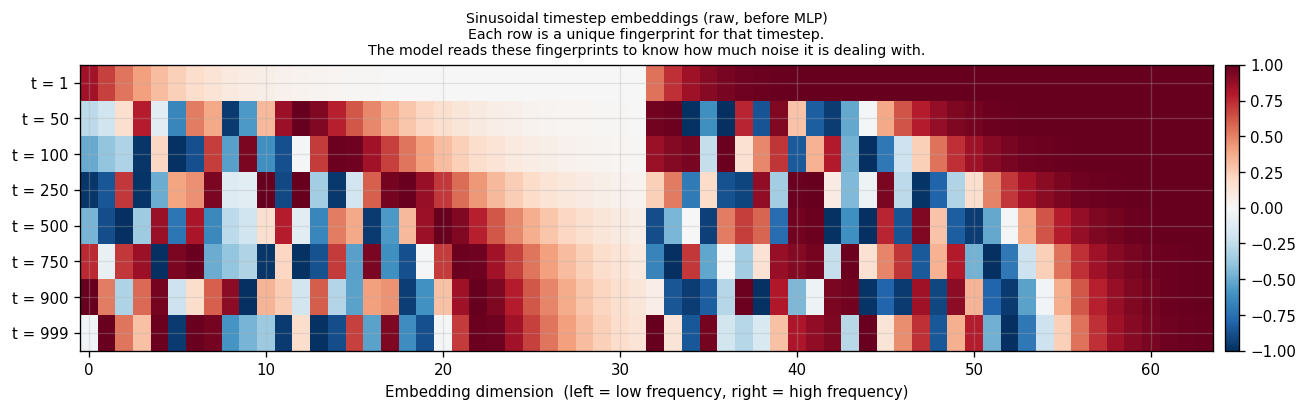

In [25]:
# ── Visualise sinusoidal embeddings for several timesteps ───────────────────
emb_module = SinusoidalTimeEmbedding(d=64)
emb_module.eval()

t_samples = [1, 50, 100, 250, 500, 750, 900, 999]
with torch.no_grad():
    raw_embs = []
    for t_val in t_samples:
        # Access the raw sinusoidal part (before MLP)
        t_f   = torch.tensor(float(t_val))
        half  = 32
        import math
        freqs = torch.exp(-math.log(10000) * torch.arange(half).float() / half)
        args  = t_f * freqs
        e_raw = torch.cat([args.sin(), args.cos()]).numpy()
        raw_embs.append(e_raw)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(np.array(raw_embs), aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(len(t_samples)))
ax.set_yticklabels([f't = {t}' for t in t_samples])
ax.set_xlabel('Embedding dimension  (left = low frequency, right = high frequency)')
ax.set_title(
    'Sinusoidal timestep embeddings (raw, before MLP)\n'
    'Each row is a unique fingerprint for that timestep.\n'
    'The model reads these fingerprints to know how much noise it is dealing with.',
    fontsize=8.5)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
plt.tight_layout()
plt.savefig('figures/theory_time_embedding.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 7  Training — The Denoising Game

### The loop

For each training step:

```
1.  Sample instance        coords, time_windows, perturbations
2.  Build features         node_feats (n,5),  edge_feats (n,n,1)
3.  Build label            y₀ = nn_tour_labels(coords)  ← binary adjacency
4.  Sample timestep        t ~ Uniform(1, T)
5.  Corrupt label          y_t = sqrt(ᾱ_t)·y₀ + sqrt(1-ᾱ_t)·ε
6.  Forward pass           ŷ₀ = model(node_feats, y_t, t, edge_feats)
7.  Loss + backprop        L = BCE(ŷ₀, y₀)   →   Adam step
```

The key design choice: **$t$ is random every step**.  
The model must learn to denoise at ALL noise levels simultaneously — from barely-corrupted ($t=1$)  
to near-random ($t=T$). This is what makes inference with an arbitrary number of steps possible.

---

### The loss function — why BCE?

We use **Binary Cross-Entropy**:

$$\mathcal{L} = -\frac{1}{n^2} \sum_{i,j} \Bigl[\;\underbrace{y_0[i,j]}_{\substack{\text{true label}\\\text{(0 or 1)}}}\, \log \underbrace{\hat{y}_0[i,j]}_{\substack{\text{predicted probability}\\\in(0,1)}} \;+\; \underbrace{(1 - y_0[i,j])}_{\text{complementary label}}\, \log\underbrace{(1 - \hat{y}_0[i,j])}_{\text{complementary probability}}\;\Bigr]$$

**where:**

| Symbol | Meaning |
|--------|---------|
| $y_0[i,j] \in \{0,1\}$ | **Ground-truth label** — 1 if edge $(i \to j)$ is in the tour, 0 otherwise |
| $\hat{y}_0[i,j] \in (0,1)$ | **Model prediction** — probability the model assigns to edge $(i \to j)$ being in the tour |
| $\log \hat{y}_0[i,j]$ | **Reward** for correct positive prediction — close to 0 when $\hat{y}_0 \approx 1$ (correct and confident) |
| $\log(1-\hat{y}_0[i,j])$ | **Reward** for correct negative prediction — close to 0 when $\hat{y}_0 \approx 0$ (correct and confident) |
| $\frac{1}{n^2}$ | Average over all $n^2$ edge pairs |

**Why not Mean Squared Error?**  
$y_0$ is **binary** — every entry is exactly 0 or 1.  
BCE is the natural loss for binary events because it heavily penalises *confident wrong predictions*:

| Prediction $\hat{y}_0$ | True $y_0$ | BCE | MSE |
|---|---|---|---|
| 0.99 | 0 | **4.6** (huge!) | 0.98 |
| 0.51 | 0 | 0.71 | 0.26 |
| 0.01 | 0 | 0.01 | 0.00 |

If the model says "99% chance this edge is in the tour" but it is not, BCE screams.  
MSE barely notices. This makes BCE a much stronger training signal for binary targets.

### What convergence looks like

At the start: model predicts ~0.5 for everything → $\mathcal{L} \approx \ln 2 \approx 0.693$  
After training: model learns to push tour edges toward 1, non-tour edges toward 0 → $\mathcal{L} \to 0$


=== One training step walkthrough ===

Step 1-3: Instance built
  node_feats: torch.Size([8, 5])  (8 nodes, 5 features each)
  y0:         torch.Size([8, 8])  (binary, 16 ones — 2 per node = 8 edges)

Step 4: Sampled t = 260

Step 5: Forward diffusion   (ᾱ_t = 0.2532)
  y_t range: [-1.558, 2.324]  (was {0,1})

Step 6: Forward pass   ŷ₀ range: [0.534, 0.555]  (∈(0,1))

Step 7: BCE loss = 0.7398
  (Random weights → expect ≈ 0.693 = ln 2)


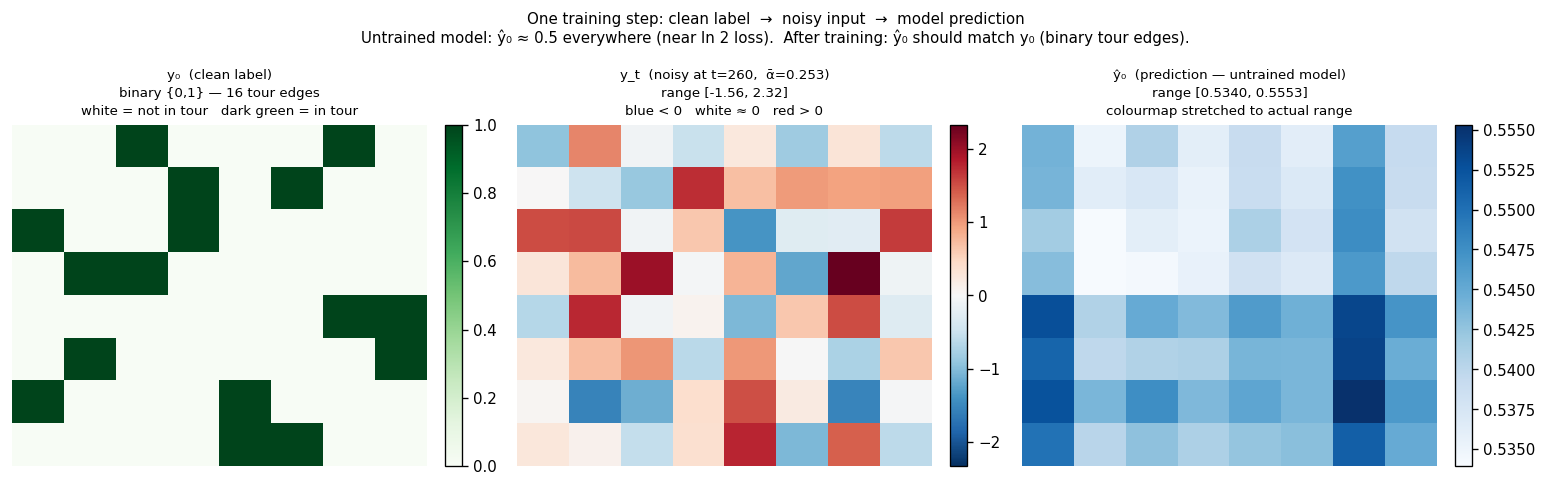

In [26]:
# ── Walk through one complete training step ─────────────────────────────────
torch.manual_seed(1)
sched_train = NoiseSchedule(T=500)

# Build a small TSPTW-D instance
c8 = random_instance(8, seed=1)
tw8, svc8 = generate_time_windows(c8, seed=1)
p8 = generate_perturbations(8, total_time=tw8[:,1].max().item(), seed=1)
nf8, ef8 = build_tsptwd_features(c8, tw8, svc8, p8)
y0_8 = nn_tour_labels(c8)

print('=== One training step walkthrough ===')
print(f'\nStep 1-3: Instance built')
print(f'  node_feats: {nf8.shape}  (8 nodes, 5 features each)')
print(f'  y0:         {y0_8.shape}  (binary, {y0_8.sum().int()} ones — 2 per node = {y0_8.sum().int()//2} edges)')

t8 = torch.randint(1, 501, (1,)).item()
print(f'\nStep 4: Sampled t = {t8}')

y_t8, eps8 = forward_diffuse(y0_8, t8, sched_train)
ab8 = sched_train.alpha_bar(t8).item()
print(f'\nStep 5: Forward diffusion   (ᾱ_t = {ab8:.4f})')
print(f'  y_t range: [{y_t8.min().item():.3f}, {y_t8.max().item():.3f}]  (was {{0,1}})')

m8 = DifuscoModel(d=64, L=4, node_dim=5, edge_dim=2)
with torch.no_grad():
    y0p8 = m8(nf8, y_t8, torch.tensor(t8), edge_extra=ef8)
print(f'\nStep 6: Forward pass   ŷ₀ range: [{y0p8.min().item():.3f}, {y0p8.max().item():.3f}]  (∈(0,1))')

loss8 = F.binary_cross_entropy(y0p8, y0_8)
print(f'\nStep 7: BCE loss = {loss8.item():.4f}')
print(f'  (Random weights → expect ≈ {float(-(0.5*torch.log(torch.tensor(0.5))*2).item()):.3f} = ln 2)')

# ── Visualise: y0 / y_t / ŷ₀ with colormaps matched to each data type ───────
#
#  y0    → Greens  (binary {0,1}: white=0, dark green=1)
#  y_t   → RdBu_r  (continuous, can be negative: blue<0, white≈0, red>0)
#  ŷ₀    → Blues   (prediction ∈(0,1): scale auto-stretched to actual range
#                   so even tiny variations from the untrained model are visible)

y0p8_d = y0p8.detach()

# Symmetric scale for y_t so zero maps to white
yt_abs = float(y_t8.abs().max())

# Stretch ŷ₀ to its own range — avoids the "all yellow at 0.5" problem
pred_lo = float(y0p8_d.min()) - 1e-4
pred_hi = float(y0p8_d.max()) + 1e-4

panels = [
    (y0_8,    'Greens',  0,        1,
     f'y₀  (clean label)\nbinary {{0,1}} — {y0_8.sum().int()} tour edges\n'
     f'white = not in tour   dark green = in tour'),
    (y_t8,    'RdBu_r', -yt_abs,  yt_abs,
     f'y_t  (noisy at t={t8},  ᾱ={ab8:.3f})\nrange [{y_t8.min():.2f}, {y_t8.max():.2f}]\n'
     f'blue < 0   white ≈ 0   red > 0'),
    (y0p8_d,  'Blues',   pred_lo,  pred_hi,
     f'ŷ₀  (prediction — untrained model)\nrange [{pred_lo:.4f}, {pred_hi:.4f}]\n'
     f'colourmap stretched to actual range'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (mat, cmap, vmin, vmax, title) in zip(axes, panels):
    im = ax.imshow(mat.numpy(), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=8, linespacing=1.5)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    'One training step: clean label  →  noisy input  →  model prediction\n'
    'Untrained model: ŷ₀ ≈ 0.5 everywhere (near ln 2 loss).  '
    'After training: ŷ₀ should match y₀ (binary tour edges).',
    fontsize=9)
plt.tight_layout()
plt.savefig('figures/theory_training_step.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8  Inference — Running the Reverse Chain

Once trained, to solve a new instance:

### DDIM reverse chain (what `sample()` does)

```
y_T  ~  N(0, I)                                 ← pure noise

for t in [T, T-20, T-40, ..., 20, 1]:           ← 50 evenly-spaced steps

    ŷ₀ = model(node_feats, y_t, t, edge_feats)  ← predict clean tour

    δ  = (y_t - sqrt(ᾱ_t) · ŷ₀)                ← estimated noise direction
          ─────────────────────────
              sqrt(1 - ᾱ_t)

    y_{t-1} = sqrt(ᾱ_{t-1}) · ŷ₀              ← blend prediction...
            + sqrt(1 - ᾱ_{t-1}) · δ            ← ...with noise direction

y₀  →  greedy_decode()  →  tour  →  evaluate_tsptwd()
```

**What each line means:**

| Step | Symbol | Meaning |
|------|--------|---------|
| Initialise | $y_T \sim \mathcal{N}(0,I)$ | Start from **pure random noise** — an $n \times n$ matrix of independent standard Gaussians |
| Predict | $\hat{y}_0 = f_\theta(y_t, x, t)$ | Ask the model: *"given this noisy state at level $t$, what clean tour do you see?"* |
| Noise direction | $\delta = (y_t - \sqrt{\bar{\alpha}_t}\,\hat{y}_0) / \sqrt{1-\bar{\alpha}_t}$ | Estimate the **direction of noise** in $y_t$ by subtracting the predicted signal component and normalising |
| Update | $y_{t-1} = \sqrt{\bar{\alpha}_{t-1}}\,\hat{y}_0 + \sqrt{1-\bar{\alpha}_{t-1}}\,\delta$ | Project to the **previous noise level**: keep the same noise direction $\delta$ but rescale signal and noise weights for step $t-1$ |
| Decode | `greedy_decode(ŷ₀)` | At the end, $\hat{y}_0 \approx y_0$ — greedily extract a valid tour from the edge probability matrix |

> **Why use the same $\delta$ at each step?**  
> Because the noise direction doesn't change — only its *amplitude* does.  
> DDIM rescales the same direction vector to match the target noise level, enabling large step-size jumps without accumulated error.

---

### Best-of-N — free quality boost

$y_T$ is **sampled fresh** each time — different random noise → different tour.  
Run the chain $N$ times and keep the **shortest tour**. No extra training needed.

```python
best_tour, best_len, all_tours = sample_best_of(
    model, node_feats, schedule,
    n_samples=8, n_steps=50
)
```

This is the TSP equivalent of generating 8 images and picking the most beautiful one.

---

### DDPM vs DDIM — when to use which

| | DDPM | DDIM |
|---|---|---|
| **Steps needed** | All $T$ (slow) | 20–100 (fast) |
| **Deterministic?** | No — adds $\varepsilon$ each step | Yes — no randomness after $y_T$ is fixed |
| **Diversity** | High — each step injects new noise | Lower — fixed $y_T$ → fixed tour |
| **Quality** | Marginally higher | Nearly identical |
| **Use case** | Research / quality benchmark | Production / best-of-N |

For best-of-N, **DDIM is better**: deterministic chains started from different $y_T$ samples  
give maximum diversity with minimum compute.


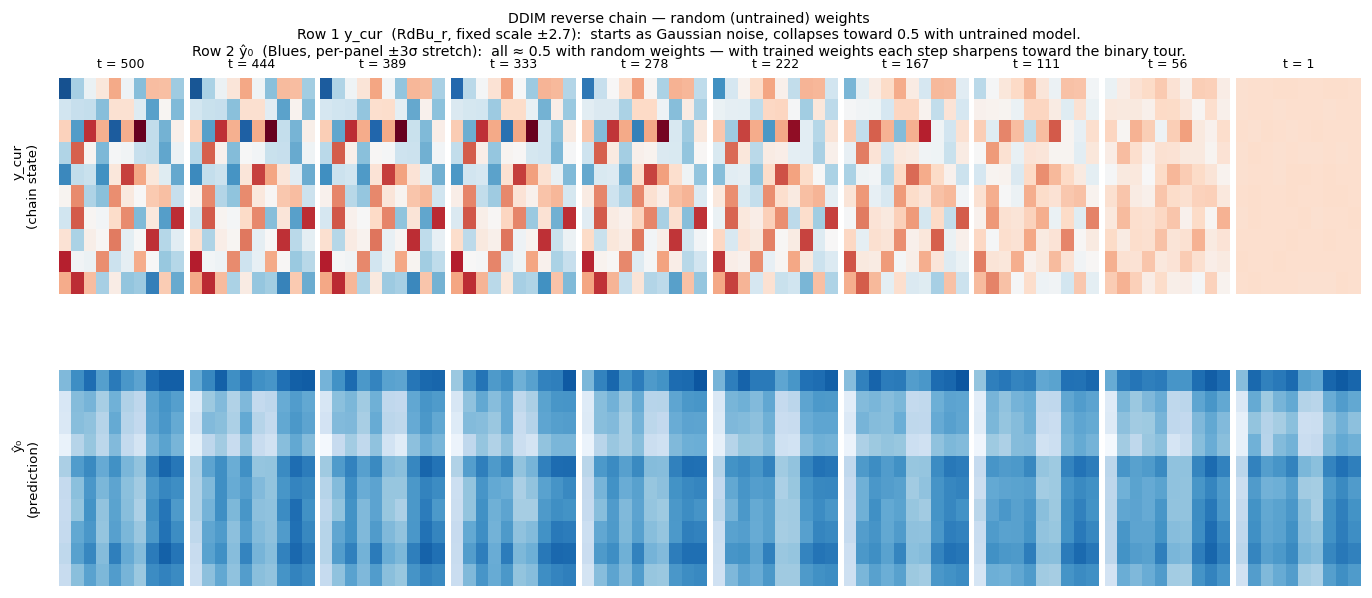

Untrained model: all ŷ₀ predictions are near 0.453 ± 0.0072
This is expected — the BCE loss starts at ≈ ln 2 ≈ 0.693.
After training, predictions sharpen to 0 or 1, matching y₀.


In [27]:
# ── Reverse chain: show both the chain state y_cur and the prediction ŷ₀ ──────
#
#  Row 0 — y_cur  (the matrix being denoised, RdBu_r, consistent scale)
#           Starts as Gaussian noise; with a TRAINED model it converges toward
#           a binary tour matrix.  With random weights it collapses toward 0.5.
#
#  Row 1 — ŷ₀     (model prediction at each step, Blues, stretched per panel)
#           With random weights all predictions are ≈ 0.5 (hence "all yellow"
#           with RdYlGn).  Stretching the colourmap to the actual range of each
#           panel reveals the tiny differences that are present even untrained.
#
from train import NoiseSchedule

m_inf  = DifuscoModel(d=64, L=4, node_dim=5, edge_dim=2)
m_inf.eval()
sch_inf = NoiseSchedule(T=500)

n_inf = 10
c_inf  = random_instance(n_inf, seed=9)
tw_inf, sv_inf = generate_time_windows(c_inf, seed=9)
pt_inf = generate_perturbations(n_inf, total_time=tw_inf[:,1].max().item(), seed=9)
nf_inf, ef_inf = build_tsptwd_features(c_inf, tw_inf, sv_inf, pt_inf)

N_STEPS   = 10
ts_inf    = torch.linspace(500, 1, N_STEPS).long().tolist()

chain_snaps = []   # (t, y_cur before update)
pred_snaps  = []   # (t, ŷ₀)

with torch.no_grad():
    y_cur = torch.randn(n_inf, n_inf)
    for idx, t_i in enumerate(ts_inf):
        chain_snaps.append((t_i, y_cur.clone()))
        t_ten = torch.tensor(t_i, dtype=torch.long)
        y0p   = m_inf(nf_inf, y_cur, t_ten, edge_extra=ef_inf)
        pred_snaps.append((t_i, y0p.clone()))
        if idx < N_STEPS - 1:
            t_p   = int(ts_inf[idx + 1])
            ab_t  = sch_inf.alpha_bar(t_i)
            ab_p  = sch_inf.alpha_bar(t_p)
            nd    = (y_cur - ab_t.sqrt() * y0p) / (1 - ab_t).clamp(min=1e-8).sqrt()
            y_cur = ab_p.sqrt() * y0p + (1 - ab_p).sqrt() * nd

# Consistent symmetric scale for y_cur (anchored on the initial Gaussian range)
y_T_abs = float(chain_snaps[0][1].abs().max())
vabs    = max(y_T_abs, 0.5)

fig, axes = plt.subplots(2, N_STEPS, figsize=(14, 5.5))
fig.subplots_adjust(hspace=0.35, wspace=0.05)

for col in range(N_STEPS):
    # ── Row 0: chain state y_cur ──────────────────────────────────────────
    t_c, y_c = chain_snaps[col]
    axes[0, col].imshow(y_c.numpy(), cmap='RdBu_r', vmin=-vabs, vmax=vabs, aspect='auto')
    axes[0, col].set_title(f't = {t_c}', fontsize=7.5)
    axes[0, col].axis('off')

    # ── Row 1: prediction ŷ₀, colourmap stretched to actual range ─────────
    t_p, y_p = pred_snaps[col]
    p_mean = float(y_p.mean())
    p_spread = max(float(y_p.std()) * 3, 1e-3)   # ≥1e-3 to avoid flat image
    axes[1, col].imshow(y_p.numpy(), cmap='Blues',
                        vmin=p_mean - p_spread, vmax=p_mean + p_spread,
                        aspect='auto')
    axes[1, col].axis('off')

# Row labels (added as text on the leftmost axes)
axes[0, 0].text(-0.15, 0.5, 'y_cur\n(chain state)', transform=axes[0, 0].transAxes,
                fontsize=8, va='center', ha='right', rotation=90)
axes[1, 0].text(-0.15, 0.5, 'ŷ₀\n(prediction)', transform=axes[1, 0].transAxes,
                fontsize=8, va='center', ha='right', rotation=90)

plt.suptitle(
    'DDIM reverse chain — random (untrained) weights\n'
    'Row 1 y_cur  (RdBu_r, fixed scale ±{:.1f}):  starts as Gaussian noise, '
    'collapses toward 0.5 with untrained model.\n'
    'Row 2 ŷ₀  (Blues, per-panel ±3σ stretch):  all ≈ 0.5 with random weights — '
    'with trained weights each step sharpens toward the binary tour.'.format(vabs),
    fontsize=8.5)

plt.savefig('figures/theory_reverse_chain.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Untrained model: all ŷ₀ predictions are near {pred_snaps[0][1].mean():.3f} ± {pred_snaps[0][1].std():.4f}')
print('This is expected — the BCE loss starts at ≈ ln 2 ≈ 0.693.')
print('After training, predictions sharpen to 0 or 1, matching y₀.')


---
## 9  Summary and Comparison with the GNN

### The complete DIFUSCO pipeline

```
TRAINING
═══════════════════════════════════════════════════════════════
 coords, TW, perturbations
        │
        ├─ build_tsptwd_features() ─→  node_feats (n,5),  edge_feats (n,n,1)
        ├─ nn_tour_labels()        ─→  y₀  (n,n)  binary tour adjacency
        │
        │  sample  t ~ Uniform(1, T)
        │  forward_diffuse(y₀, t)  ─→  y_t  (noisy version of y₀)
        │
        └─ DifuscoModel(node_feats, y_t, t, edge_feats)
                 │
                 └─→  ŷ₀  (n,n)  ─→  BCE(ŷ₀, y₀)  ─→  Adam

INFERENCE
═══════════════════════════════════════════════════════════════
 y_T ~ N(0, I)
     │
     │  for t = T … 1  (50 DDIM steps):
     │      ŷ₀ = DifuscoModel(node_feats, y_t, t, edge_feats)
     │      y_{t-1} = DDIM_step(ŷ₀, y_t, ᾱ_t, ᾱ_{t-1})
     │
     ŷ₀  ─→  greedy_decode()  ─→  tour  ─→  evaluate_tsptwd()
```

---

### DIFUSCO vs GNN

| | GNN (Joshi et al., 2019) | DIFUSCO (Sun & Yang, 2023) |
|---|---|---|
| **Architecture** | GCN layers | Same GCN layers + timestep embedding |
| **Key extra input** | — | Noisy tour $y_t$ |
| **Inference passes** | **1** | 50–1000 |
| **Stochastic?** | No — always same answer | Yes — different $y_T$ → different tours |
| **Best-of-N** | No | Yes — huge free quality gain |
| **Inference time** | ~1 ms | ~50–1000× slower |
| **Solution quality** | Good | State of the art |
| **Good for** | Real-time, large $n$ | Best quality, time available |

---

### Key papers

- **DIFUSCO**: Sun, Z. & Yang, Y. — *DIFUSCO: Graph-based Diffusion Solvers for Combinatorial Optimization*, NeurIPS 2023
- **DDPM**: Ho, J., Jain, A. & Abbeel, P. — *Denoising Diffusion Probabilistic Models*, NeurIPS 2020
- **DDIM**: Song, J., Meng, C. & Ermon, S. — *Denoising Diffusion Implicit Models*, ICLR 2021
- **GNN backbone**: Joshi, C., Laurent, T. & Bresson, X. — *An Efficient Graph Convolutional Network Technique for the TSP*, 2019
